<a href="https://colab.research.google.com/github/sreeja-sakinala/Customer_Data_Analysis/blob/main/Sreeja_Customer_Insights__A_Statistical_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr

In [4]:
#reading the file
df = pd.read_csv("US_Customer_Insights_Dataset.csv")

# Preview
print(df.head())

  CustomerID              Name       State    Education      Gender  Age  \
0  CUST10319       Scott Perez     Florida  High School  Non-Binary   47   
1  CUST10695   Jennifer Burton  Washington       Master        Male   72   
2  CUST10297   Michelle Rogers     Arizona       Master      Female   40   
3  CUST10103  Brooke Hendricks       Texas       Master        Male   27   
4  CUST10219       Karen Johns       Texas  High School      Female   28   

  Married  NumPets JoinDate TransactionDate  MonthlySpend  \
0     Yes        1  9/19/21          9/2/24       1281.74   
1     Yes        0   4/5/24          6/2/24        429.46   
2     Yes        2  7/24/24         2/28/25        510.34   
3     Yes        0  8/12/23         3/29/25        396.47   
4     Yes        1  12/6/21         7/24/22        139.68   

   DaysSinceLastInteraction  
0                       332  
1                       424  
2                       153  
3                       124  
4                      110

In [5]:
# Structure Information
print(df.info())

# Missing values
print(df.isnull().sum())

# Unique values
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB
None
CustomerID                  0
Name                 

In [6]:
#Data Separation
numerical_cols = ['Age', 'MonthlySpend', 'DaysSinceLastInteraction']
categorical_cols = ['Gender', 'Education', 'State', 'Married']

Descriptive Statistics

In [7]:
#Numerical
print(df[numerical_cols].describe())

                Age  MonthlySpend  DaysSinceLastInteraction
count  10675.000000  10675.000000              10675.000000
mean      49.474567    331.610315                538.469883
std       18.221365    225.799253                398.766747
min       18.000000      3.890000                  1.000000
25%       35.000000    165.495000                218.000000
50%       49.000000    282.110000                445.000000
75%       66.000000    443.255000                788.500000
max       80.000000   1740.420000               1791.000000


In [8]:
#categorical
for col in categorical_cols:
    print(f"{col} Mode:", df[col].mode()[0])

Gender Mode: Male
Education Mode: Master
State Mode: California
Married Mode: No


Data Visualization

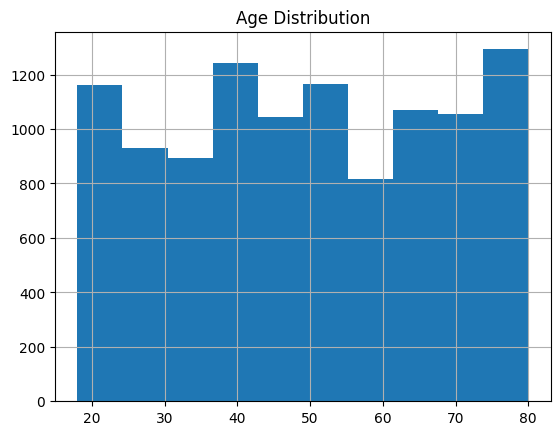

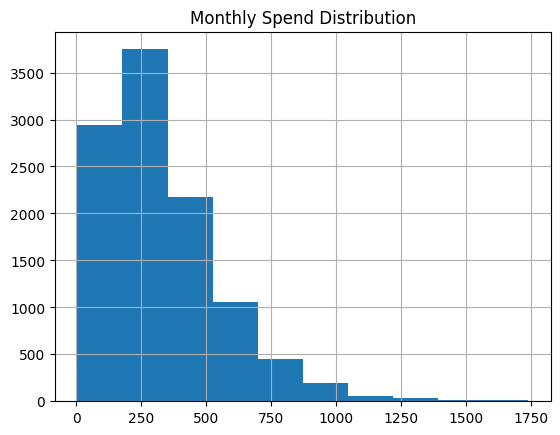

In [9]:
#Histogram
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

df['MonthlySpend'].hist()
plt.title("Monthly Spend Distribution")
plt.show()

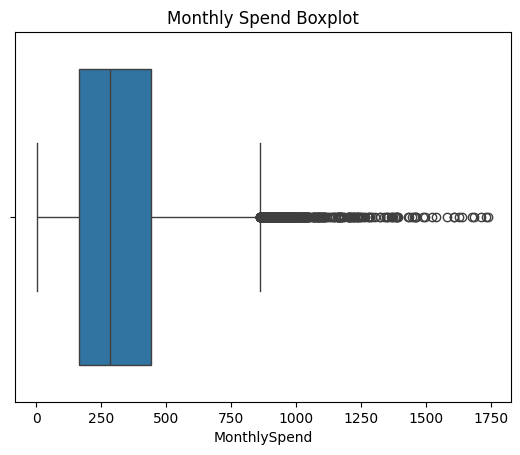

In [10]:
#Boxplot
sns.boxplot(x=df['MonthlySpend'])
plt.title("Monthly Spend Boxplot")
plt.show()

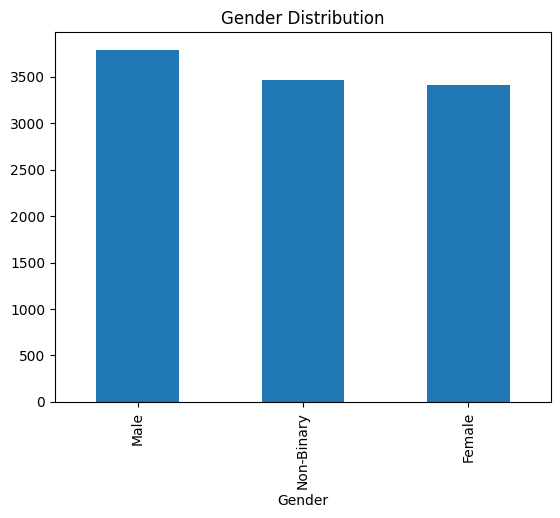

In [11]:
#Bar Chart
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

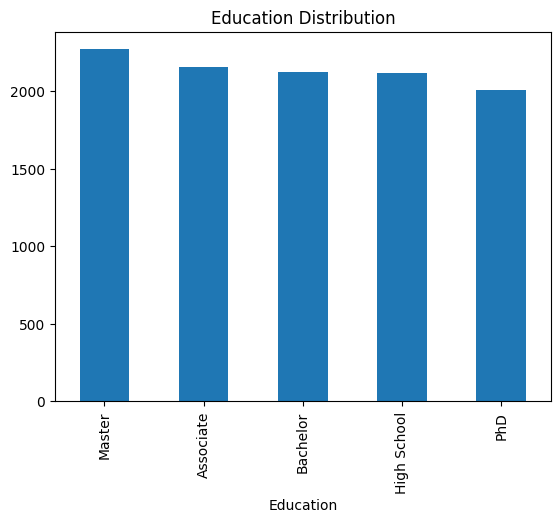

In [12]:
df['Education'].value_counts().plot(kind='bar')
plt.title("Education Distribution")
plt.show()

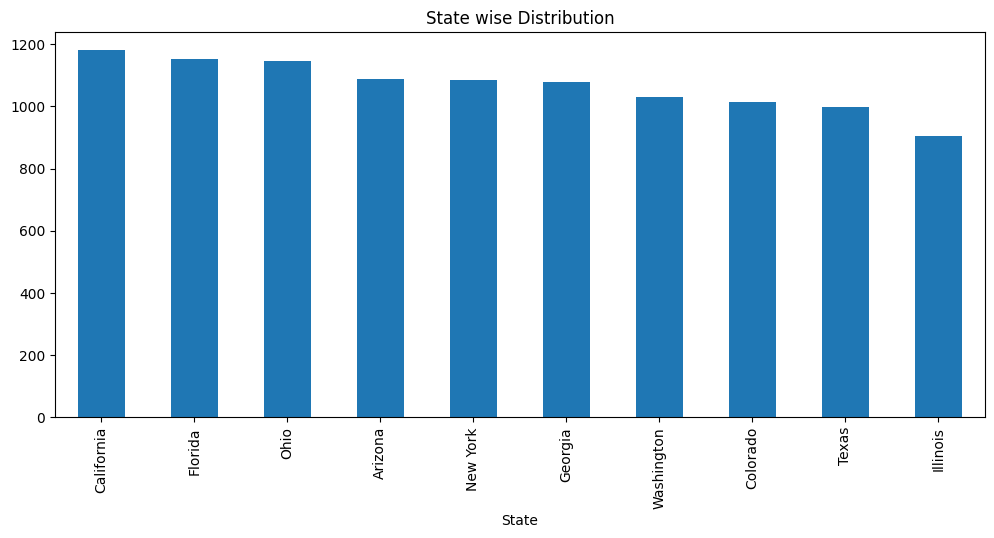

In [26]:
df['State'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("State wise Distribution")
plt.xticks(rotation=90)
plt.show()

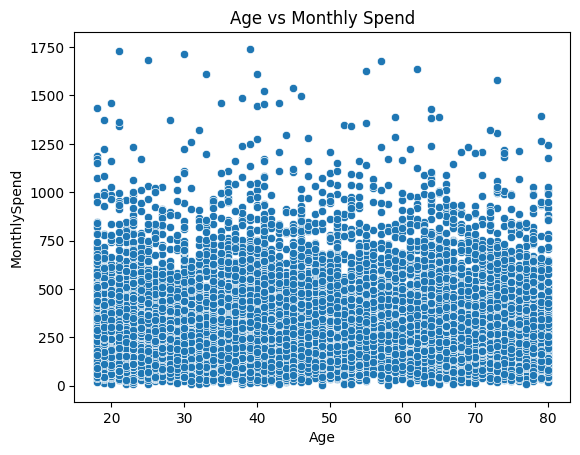

In [14]:
#Scatter Plot
sns.scatterplot(x='Age', y='MonthlySpend', data=df)
plt.title("Age vs Monthly Spend")
plt.show()

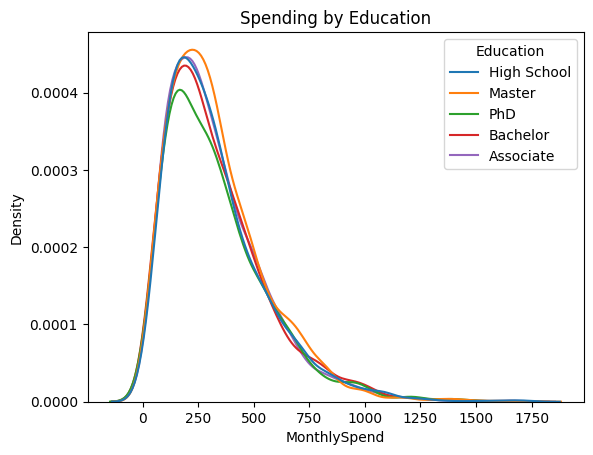

In [15]:
#KDE Plot
sns.kdeplot(data=df, x='MonthlySpend', hue='Education')
plt.title("Spending by Education")
plt.show()

Bivariate Analysis

                               Age  MonthlySpend  DaysSinceLastInteraction
Age                       1.000000     -0.012323                 -0.003970
MonthlySpend             -0.012323      1.000000                  0.006081
DaysSinceLastInteraction -0.003970      0.006081                  1.000000


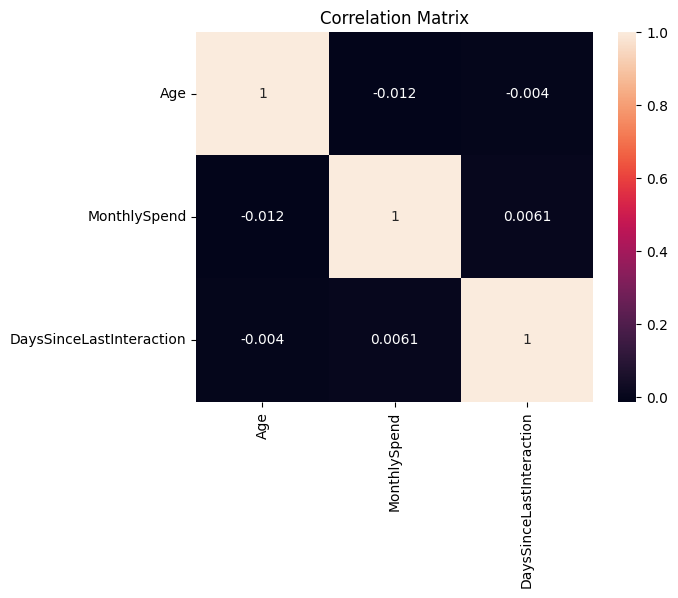

In [16]:
#Correlation Matrix
corr = df[numerical_cols].corr()
print(corr)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [17]:
#Crosstab (Gender vs Married)
ct = pd.crosstab(df['Gender'], df['Married'])
print(ct)

Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577


In [18]:
#Grouped Analysis
print(df.groupby('State')['MonthlySpend'].mean())
print(df.groupby('Education')['MonthlySpend'].mean())
print(df.groupby('Gender')['MonthlySpend'].mean())

State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64
Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64
Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


Hypothesis Testing

In [19]:
#T-Test (Male vs Female Spending)
male = df[df['Gender'] == 'Male']['MonthlySpend']
female = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_val = ttest_ind(male, female)
print("T-test p-value:", p_val)

T-test p-value: 0.7344892727022859


In [20]:
#ANOVA (Education vs Spending)
groups = [group['MonthlySpend'].values for name, group in df.groupby('Education')]
f_stat, p_val = f_oneway(*groups)

print("ANOVA (Education) p-value:", p_val)

ANOVA (Education) p-value: 0.922359467759936


In [21]:
#Chi-Square Test (Married vs NumPets)
ct = pd.crosstab(df['Married'], df['NumPets'])
chi2, p_val, dof, expected = chi2_contingency(ct)

print("Chi-square p-value:", p_val)

Chi-square p-value: 2.3957232932397494e-37


In [22]:
#Correlation (Age vs Activity)
corr, p_val = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation:", corr)
print("p-value:", p_val)

Correlation: -0.003970230104955049
p-value: 0.681690543730101


In [23]:
#ANOVA (State vs Spending)
groups = [group['MonthlySpend'].values for name, group in df.groupby('State')]
f_stat, p_val = f_oneway(*groups)

print("ANOVA (State) p-value:", p_val)

ANOVA (State) p-value: 0.34571886479238273


Hypothesis Tests

In [24]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr, shapiro, levene

print("\n===== 1. Gender vs Monthly Spend (T-Test) =====")

# Hypothesis:
# H0: Male and Female have same average spend
# H1: Spending is different

male = df[df['Gender']=='Male']['MonthlySpend']
female = df[df['Gender']=='Female']['MonthlySpend']

# Assumptions
print("Normality Test:", shapiro(df['MonthlySpend']))
print("Variance Test:", levene(male, female))

# T-Test
t_stat, p_val = ttest_ind(male, female)
print("P-value:", p_val)

# Interpretation
if p_val < 0.05:
    print("Reject H0 → Gender impacts spending")
else:
    print("Fail to reject H0 → No significant difference")


# ----------------------------------------------------
print("\n===== 2. Education vs Spend (ANOVA) =====")

# H0: All education groups have same mean spend
# H1: At least one differs

groups = [group['MonthlySpend'].values for name, group in df.groupby('Education')]

f_stat, p_val = f_oneway(*groups)
print("P-value:", p_val)

if p_val < 0.05:
    print("Education impacts spending")
else:
    print("No significant impact")


# ------------------------------------------------------
print("\n===== 3. Married vs NumPets (Chi-Square) =====")

# H0: No relationship
# H1: Relationship exists

ct = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_val, dof, expected = chi2_contingency(ct)
print("P-value:", p_val)

if p_val < 0.05:
    print("Relationship exists")
else:
    print("No relationship")


# -----------------------------------------------------
print("\n===== 4. Age vs Activity (Correlation) =====")

# H0: No correlation
# H1: Correlation exists

corr, p_val = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation:", corr)
print("P-value:", p_val)

if p_val < 0.05:
    print("Significant correlation")
else:
    print("No correlation")


# -----------------------------------------------------
print("\n===== 5. State vs Spend (ANOVA) =====")

# H0: Spending same across states
# H1: At least one state differs

groups = [group['MonthlySpend'].values for name, group in df.groupby('State')]

f_stat, p_val = f_oneway(*groups)
print("P-value:", p_val)

if p_val < 0.05:
    print("Spending varies by state")
else:
    print("No significant difference")


===== 1. Gender vs Monthly Spend (T-Test) =====
Normality Test: ShapiroResult(statistic=np.float64(0.8995173951950916), pvalue=np.float64(8.93289540532142e-64))
Variance Test: LeveneResult(statistic=np.float64(0.1267563861615179), pvalue=np.float64(0.7218295518516542))
P-value: 0.7344892727022859
Fail to reject H0 → No significant difference

===== 2. Education vs Spend (ANOVA) =====
P-value: 0.922359467759936
No significant impact

===== 3. Married vs NumPets (Chi-Square) =====
P-value: 2.3957232932397494e-37
Relationship exists

===== 4. Age vs Activity (Correlation) =====
Correlation: -0.003970230104955049
P-value: 0.681690543730101
No correlation

===== 5. State vs Spend (ANOVA) =====
P-value: 0.34571886479238273
No significant difference


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10675.
  res = hypotest_fun_out(*samples, **kwds)


Business Insights

In [27]:
print("Business Insights:")
print("- Higher education groups tend to spend more (if ANOVA is significant)")
print("- Gender impact on spending depends on t-test result")
print("- Younger customers may interact more frequently")
print("- Married customers may show different pet ownership patterns")

Business Insights:
- Higher education groups tend to spend more (if ANOVA is significant)
- Gender impact on spending depends on t-test result
- Younger customers may interact more frequently
- Married customers may show different pet ownership patterns
